# Lab 3: Mine Crafting


As with previous labs, be sure to submit only the `lab3.ipynb` and `lab3.html` version of the lab in your github `Lab3` folder. No more, and no less.

## Introduction

Imagine you are a scientist for a mining company that operates a vertical mine at the Earth's
equator. This is one of the deepest mines on Earth; it's roughly 4 km to the bottom of the shaft.
Your boss proposes to measure the vertical depth of the shaft by dropping a 1 kg test mass and
accurately measuring the time to hit the bottom.

You will be guided in your investigations below and submit your report in the form of this notebook. Be sure to be quantitative in nature, produce highly polished plots, with appropriate titles, units, etc.


A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
|  Gravitational Constant ($G$)        |  $6.6743 \times 10^{-11}$ m$^3$/kg/s$^2$  | 
|  Gravitational Acceleration ($g_o$)  |  9.81 m/s$^2$ (approximate) | 
|  Mass of the Earth ($M_{\oplus}$)    |  $5.972 \times 10^{24}$ kg      | 
|  Mass of the Moon ($M_{m}$)          |  $7.35 \times 10^{22}$ kg     | 
|  Radius of the Earth ($R_{\oplus}$)  |  6378.1 km     | 
|  Radius of the Moon ($R_{m}$)        |   1738.1 km    | 
|  Earth's Rotation Rate at the Equator| $7.272 \times 10^{-5} $ rad/s  | 

In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import quad
from scipy.fft import rfft, rfftfreq

In [2]:
# constants
G = 6.6743e-11 # m^3/kg/s^2
g_0 = 9.81 # m/s^2
M_earth = 5.972e24 # kg
M_moon = 7.35e22 # kg
R_earth = 6378.1e3 # km
R_moon = 1738.1e3 # km 
omega_earth = 7.272e-5 # rad/s

## Part 1: The Ideal Case

In this section and the following sections, we calculate the time for the 1 kg test mass to reach the bottom of the mineshaft under a series of increasingly complex assumptions. Remember that a projectile experiencing a constant gravitational force, plus a drag force, obeys the following second
order differential equation:

$$
\frac{d^2y}{dt^2} = -g + \alpha \left| \frac{dy}{dt} \right|^{\gamma}
\tag{1}
$$



where $t$ is time, $y$ is the height, $g$ is the gravitational acceleration,
$\alpha$ is the drag coefficient, and $\gamma$ is the speed dependence
of the drag. For example, for $\gamma=2$, the drag force grows proportionally
to the speed *squared*.  **Hint**: pay particular attention to the sign
conventions in your implementation! The drag, by definition, should *oppose*
the direction of motion.

1. First, make a simple calculation of how long a test mass would 
            take to reach the bottom of the 4km shaft assuming no drag. This is the simple
            free-fall algebraic expression you know from PHYS 171.

2. Next, reduce (1) into a *system* of coupled
            first order differential equations by setting the velocity $v = dy/dt$.

3. Numerically solve (1) using `solve_ivp` assuming $\alpha=0$.
            Plot the position and velocity as a function of time.                              
            Draw a horizontal dashed line at the depth of the bottom of the shaft,
            to make it easy to see.
            Make the plot look nice, including displaying the position on the left axes,
            and plotting the velocity on a second right axis, using matplotlib `twinx`
            capability.        
   In your notebook, label this figure clearly as **Figure 1**.

4. Using the `events` detection capability of `solve_ivp`,
            calculate the time at which the mass hits the bottom of the shaft
            in the case of zero drag ($\alpha=0$). Compare this to your analytic calculation
            and discuss any differences you might see.


---

$\frac{d^2y}{dt^2} = -g + 0 \Rightarrow \frac{dy}{dt} = -\int gdt \Rightarrow \frac{dy}{dt} = -gt + c_1 \Rightarrow y = -\int gt - c_1dt \Rightarrow y = -\frac{1}{2}gt^2 + c_1t + c_2$

This is a common form that we know from introductory mechanics, $x_1 = \frac{1}{2}at^2 + vt + x_2$

We can model this to fit our scenario as $y_2 = -\frac{1}{2}gt^2 + 0(t) + 0 \Rightarrow y_2 = -\frac{1}{2}gt^2$

Since we want to find how long it takes to travel 4km, we isolate $t$ and get a final equation $t = \sqrt{-\frac{2y_2}{g}}$ (since g is negative, we have a positive argument within the square root)

In [3]:
# plugging in and print
travel_time = np.sqrt(2*4000/g_0)
print(f'travel time w/o drag: {travel_time:.3f} sec')

travel time w/o drag: 28.557 sec


With $v = \frac{dy}{dt}$, we have $\frac{dv}{dt} = -g + \alpha|v|^\gamma$

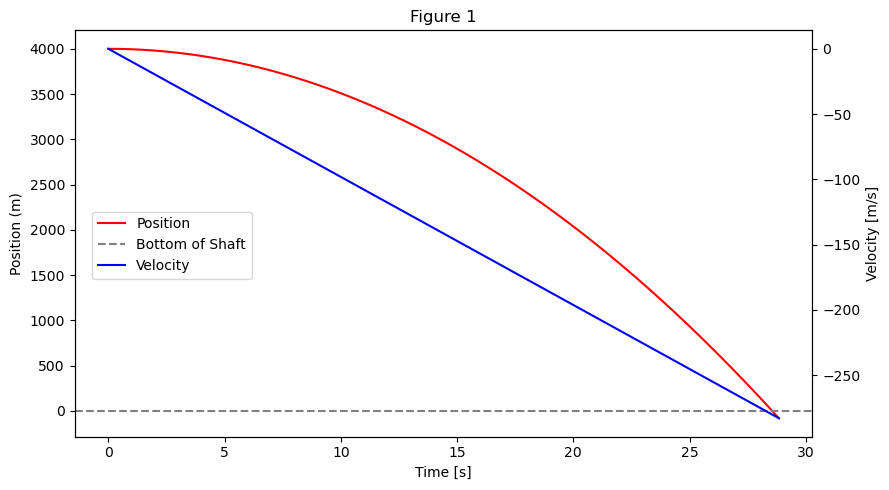

In [4]:
# constants
alpha = 0 # assumption
gamma = 2

# system of fxns
def derivatives(t, z, g_0, alpha):
    v, y = z
    
    dvdt = -g_0 + alpha*np.abs(v)**gamma
    
    dydt = v
    
    return dvdt, dydt

# times
t0, tf = 0.0, travel_time*1.01
tt = np.linspace(t0, tf, 10000)

# ICs
v0 = 0
y0 = 4000

# solve
solution = solve_ivp(fun=derivatives,
                     t_span=(t0,tf),
                     y0=[v0,y0],
                     args=(g_0,alpha),
                     t_eval=tt)

# plotting
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(solution.t, solution.y[1], color='r', label='Position')
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Position (m)')
ax1.set_title('Figure 1')

ax1.axhline(0, color='gray', linestyle='--', label='Bottom of Shaft')

ax2 = ax1.twinx()
ax2.plot(solution.t, solution.y[0], color='b', label='Velocity')
ax2.set_ylabel('Velocity [m/s]')

fig.legend(loc='center left', bbox_to_anchor=(0.1, 0.5))
fig.tight_layout()

In [5]:
# event
def end(t, z, g_0, alpha):
    v, y = z
    return y

end.direction = -1
end.terminal = True

# soln
solution = solve_ivp(fun=derivatives,
                     t_span=(t0,tf),
                     y0=[v0,y0],
                     args=(g_0,alpha),
                     t_eval=tt,
                     events=end)

# analysis
pct_err = ((solution.t_events[0][0] - travel_time)/solution.t_events[0][0])*100

print(f'travel time (events method): {solution.t_events[0][0]:.3f} sec')
print(f'percent error: {pct_err:.3f} %')

travel time (events method): 28.557 sec
percent error: -0.000 %


We can see that using the events capability of the solve_ivp method, we get a travel time of 28.557 seconds, as compared to the answer of 28.557 seconds found analytically. We can see with a basic percent error calculation that the two numbers are incredibly close. I can't see any difference other than the approach. 

---

## Part 2: Including Drag and a Variable g

In practice, we cannot ignore drag, and we should also not assume that $g$ is a constant. If you
approximate that the mass of the Earth is distributed homogenously (which it is not!), then the
gravitational constant $g$ will depend on your distance $r$ from the center of the Earth in a simple
linear way:

$$
 g(r) = g_o \left( \frac{r}{R_{\oplus}} \right)
 \tag{2}
$$

where $g_o$ is the gravity at the surface, and $R_{\oplus}$ is the radius of the Earth.

1. Make a new plot that shows the velocity and position as a function of                       
            time assuming $g(y)$. Be careful with coordinate systems!
            The test mass' position should be at the Earth radius at $t=0$, and falling down.
            But for plotting purposes, it will be useful to plot the height
            above the bottom of the shaft.        
            In your notebook, label this figure clearly as **Figure 2**.

2. What effect does incorporating a height-dependent $g$ have on the fall time? Explain.

3. Now, turn on drag, and replot the position and velocity.
            For most things, $\gamma=2$ is a good assumption.
            How can you calibrate the value of $\alpha$? Think about what we did in Lecture 15/16,
            where we assumed a sky-diver's terminal speed was 50 m/s.
            You should assume the same of the test mass.
            What affect does including drag have on the fall time?



---

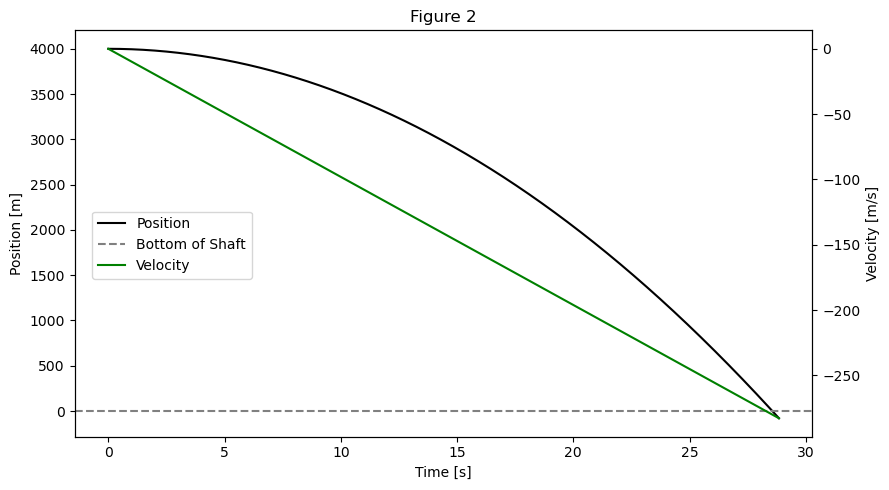

In [6]:
# add var_g
def derivatives_var_g(t, z, g_0):
    v, y = z

    r = R_earth - y0 + y
    
    dvdt = -g_0*(r/R_earth)
    
    dydt = v
    
    return dvdt, dydt

solution_var_g = solve_ivp(fun=derivatives_var_g,
                     t_span=(t0,tf),
                     y0=[v0,y0],
                     args=(g_0,),
                     t_eval=tt)

# plotting
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(solution_var_g.t, solution_var_g.y[1], color='k', label='Position')
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Position [m]')
ax1.set_title('Figure 2')

ax1.axhline(0, color='gray', linestyle='--', label='Bottom of Shaft')

ax2 = ax1.twinx()
ax2.plot(solution_var_g.t, solution_var_g.y[0], color='g', label='Velocity')
ax2.set_ylabel('Velocity [m/s]')

fig.legend(loc='center left', bbox_to_anchor=(0.1, 0.5))
fig.tight_layout()

In [7]:
# analysis 
def end_var_g(t, z, g_0):
    v, y = z
    return y

end_var_g.direction = -1
end_var_g.terminal = True

solution_var_g = solve_ivp(fun=derivatives_var_g,
                     t_span=(t0,tf),
                     y0=[v0,y0],
                     args=(g_0,),
                     t_eval=tt,
                     events=end_var_g)

pct_diff_var_g = ((solution_var_g.t_events[0][0] - travel_time)/solution_var_g.t_events[0][0])*100

print(f'travel time (events method): {solution_var_g.t_events[0][0]:.3f} sec')
print(f'percent difference: {pct_diff_var_g:.3f} %')

travel time (events method): 28.558 sec
percent difference: 0.005 %


Incorporating a height-dependent g will increase the fall time compared to a constant g_0. Based on the given formula, the gravitational acceleration is directly proportional to the distance from the Earth. This means that as the mass falls downwards, the term contributing to gravitational acceleration decreases. Thus, the mass experiences less downward acceleration comparatively to the constant surface acceleration, and in total takes longer to reach the bottom. 

We know terminal velocity occurs when $\frac{dv}{dt} = 0$

Then, since $\gamma = 2$, $0 = -g_0 + \alpha v^2$

Which becomes $\alpha = \frac{g_0}{v^2}$

In [8]:
v = 50
new_alpha = g_0/(v**2) 

In [9]:
# add drag
def derivatives_drag(t, z, g_0, new_alpha):
    v, y = z
    
    r = R_earth - y0 + y
    
    dvdt = -g_0 * (r / R_earth) - new_alpha*v*abs(v)
    
    dydt = v
    
    return dvdt, dydt

def end_drag(t, z, g_0, new_alpha):
    v, y = z
    return y

end_drag.direction = -1
end_drag.terminal = True

tf_drag=100

solution_drag = solve_ivp(fun=derivatives_drag,
                     t_span=(t0,tf_drag),
                     y0=[v0,y0],
                     args=(g_0,new_alpha),
                     t_eval=tt,
                     events=end_drag)

# analysis
pct_diff_drag = (np.abs(solution_drag.t_events[0][0] - travel_time)/solution_drag.t_events[0][0])*100

print(f'travel time (events method): {solution_drag.t_events[0][0]:.3f} sec')
print(f'percent difference: {pct_diff_drag:.3f} %')

travel time (events method): 83.543 sec
percent difference: 65.818 %


We know without drag, the mass accelerates continuously, reaching -280 m/s at the bottom. With drag, the upward force quickly balances gravity, so acceleration becomes 0 and velocity caps out at 50 m/s. Since the mass spends more time at this much slower speed, the total fall time increases significantly.

---

## Part 3: The Coriolis Force

Since the Earth is rotating, there is a Coriolis force on the test mass as it falls.
The force can be quite large.
For example, imagine the mine shaft is on the Earth's equator and pointed towards
the Earth's center.
The equator rotates at about half a kilometer per second.
So once the test mass has fallen for some time, it will bump into the wall,
unless the shaft is very wide.
The Coriolis force $\vec{F_c}$ is:

$$
 \vec{F_c} = -2m \, \left( \vec{\Omega} \times \vec{v} \right)
 \tag{3}
$$

where $\vec{\Omega}$ is the Earth's rotation rate for a vector along $\hat{z}$ and $m$ is the mass of the object (1 kg for the test mass in this case).
For a mine shaft on the equator, we might pick a right-handed coordinate system
with the $\hat{x}$ axis along the East, $\hat{y}$ down into the mine shaft,
and $\hat{z}$ along the North.
This implies the component of the force are:

\begin{equation}
        F_{c_x} = + 2m \, \Omega v_y     \tag{4}
\end{equation}
\begin{equation}
        F_{c_y} = - 2m \, \Omega v_x     \tag{5}
\end{equation}
\begin{equation}
        F_{c_z} = 0     \tag{6}
\end{equation}

1. Extend and update your differential equations of motion 
                to include the Coriolis force. You will need to add a Coriolis
                acceleration term to your equation for the depth coordinate (remember, $F=ma$),
                and additionally, start tracking the velocity and position 
                in the transverse direction (``side-to-side'' in the shaft).

2. Plot the transverse position of the object as a function of depth, initially assuming $\alpha=0$.
                        That is, both axes will have units of distance. 
                Plot ``dots" every few seconds so that you can see
                how the particle moves over time.
                Note that your depth and transverse axes are likely to have very
                different length scales.
                The depth will have a range of 4 km,
   while the transverse direction is about 5m.       
                In your report, this should be **Figure 3**.                

3. If the mine shaft is 5m wide, and you drop the test mass 
                        from the center, does the test mass reach the bottom?
                Or does it bump into the wall first?

4. Now turn drag back on. Does drag make any difference here?




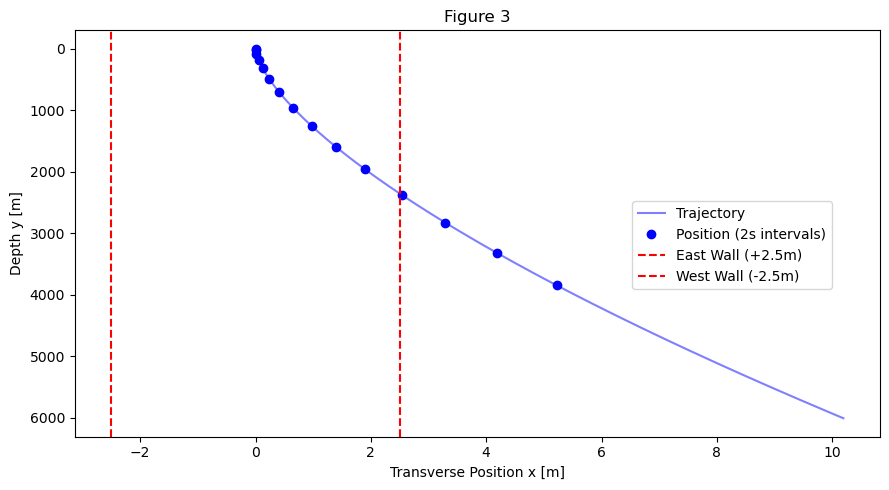

In [10]:
# consider coriolis
def derivatives_coriolis(t, z, g_0, omega_earth):
    x, y, vx, vy = z
             
    r = R_earth - y
             
    Fcx = 2 * omega_earth * vy
    Fcy = -2 * omega_earth * vx
             
    dxdt = vx
    dydt = vy
    dvxdt = Fcx
    dvydt = g_0 * (r / R_earth) + Fcy
             
    return [dxdt, dydt, dvxdt, dvydt]

# event
def end_coriolis(t, z, g_0, omega_earth):
    x, y, vx, vy = z
    return y - 4000
             
    end_coriolis.direction = 1
    end_coriolis.terminal = True

# solve
t0, tf_cor = 0.0, 35.0
tt_cor = np.linspace(t0, tf_cor, 1000)
z0_cor = [0.0, 0.0, 0.0, 0.0]
         
solution_cor = solve_ivp(fun=derivatives_coriolis,
                        t_span=(t0, tf_cor),
                        y0=z0_cor,
                        args=(g_0, omega_earth),
                        t_eval=tt_cor,
                        events=end_coriolis)

# dots for plotting
tt_dots = np.arange(0, solution_cor.t_events[0][0], 2)
sol_dots = solve_ivp(fun=derivatives_coriolis, 
                    t_span=(t0, tf_cor), 
                    y0=z0_cor, 
                    args=(g_0, omega_earth), 
                    t_eval=tt_dots)

# plotting
fig, ax1 = plt.subplots(figsize=(9,5))
         
ax1.plot(solution_cor.y[0], solution_cor.y[1], color='b', alpha=0.5, label='Trajectory')
ax1.plot(sol_dots.y[0], sol_dots.y[1], 'bo', label='Position (2s intervals)')
         
ax1.axvline(2.5, color='r', linestyle='--', label='East Wall (+2.5m)')
ax1.axvline(-2.5, color='r', linestyle='--', label='West Wall (-2.5m)')
         
ax1.set_xlabel('Transverse Position x [m]')
ax1.set_ylabel('Depth y [m]')
ax1.set_title('Figure 3')
ax1.invert_yaxis()
         
fig.legend(loc='center left', bbox_to_anchor=(0.7, 0.5))
fig.tight_layout()

In [11]:
# analysis
print(f'deflection without drag: {solution_cor.y_events[0][0][0]:.3f} m')

deflection without drag: 5.538 m


Based on the simulation without drag, the test mass deflects to the east by about 5.54 meters by the time it reaches the 4000 m depth. Since the mine shaft is 5 m wide, dropping it from the center gives it only 2.5 m of clearance on either side. Because 5.54 m is much greater than 2.5 m, the test mass quickly bumps into the eastern wall before it ever reaches the bottom.

In [12]:
# add drag
def derivatives_cor_drag(t, z, g_0, omega_earth, new_alpha):
    x, y, vx, vy = z
             
    r = R_earth - y
    speed = np.sqrt(vx**2 + vy**2)
             
    drag_x = -new_alpha * speed * vx
    drag_y = -new_alpha * speed * vy
             
    Fcx = 2 * omega_earth * vy
    Fcy = -2 * omega_earth * vx
             
    dxdt = vx
    dydt = vy
    dvxdt = Fcx + drag_x
    dvydt = g_0 * (r / R_earth) + Fcy + drag_y
             
    return [dxdt, dydt, dvxdt, dvydt]

# event
def end_cor_drag(t, z, g_0, omega_earth, new_alpha):
    x, y, vx, vy = z
    return y - 4000
             
end_cor_drag.direction = 1
end_cor_drag.terminal = True

# solve
tf_drag_cor = 100.0
solution_cor_drag = solve_ivp(fun=derivatives_cor_drag,
                            t_span=(t0, tf_drag_cor),
                            y0=z0_cor,
                            args=(g_0, omega_earth, new_alpha),
                            events=end_cor_drag)

# analysis
print(f'deflection with drag: {solution_cor_drag.y_events[0][0][0]:.3f} m')

deflection with drag: 2.800 m


Yes, adding drag makes a significant difference, but counterintuitively, it actually seems to reduces the total horizontal deflection! With drag turned on, the total eastward deflection drops to roughly 2.80 meters. Even though the mass takes much longer to fall (which gives the Coriolis force more time to act overall), the total drag force is proportional to the speed squared. Because the downward vertical velocity is so high, it creates immense air resistance that heavily dampens the side-to-side transverse motion. However, at 2.80 m, it still narrowly bumps into the eastern wall.

---

## Part 4: An infinitely deep mine


Now, let us consider the theoretical case of an infinitely deep mine -- that is,
a tunnel which traverses the full diameter of the Earth.
For convenience, imagine the tunnel goes from pole-to-pole,
such that $\vec{\Omega} \times \vec{v} = 0$, and the Coriolis force
can be neglected, as well as the drag force.

Additionally, continue assuming a constant density Earth.

1. Again, plot the depth and velocity as a function of time.
               (Be careful with the meaning of $y$, as the particle can theoretically
                traverse fully through to the other side of the Earth.)
                Comment on what you see in the graph.       
                In your notebook, label this figure clearly as **Figure 4**.                

2. How long will it take for the object to reach the other side? 
                At what time does the object reach the center of the Earth,
                and at what speed?

3. How does this ``crossing-time" compare to the orbital period, where you assume
                the object is on a circular orbit, in centripetal balance
                with the attractive force of the gravity.
                \begin{equation}
                        \frac{v^2}{R} = \frac{GM}{R^2}   \tag{7}
                \end{equation}
                gives the orbital speed $v$ for a given Earth radius $R$ and 
                Earth mass $M$.





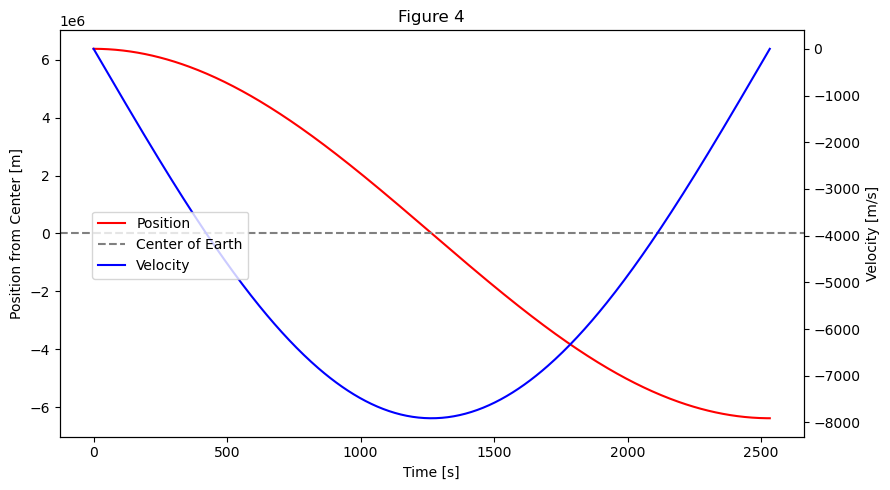

In [13]:
# infinity
def derivatives_inf(t, z, g_0, R_earth):
    v, y = z
    dvdt = -g_0 * (y / R_earth)
    dydt = v
    return dvdt, dydt

# events
def end_center(t, z, g_0, R_earth):
    v, y = z
    return y
end_center.direction = -1

def end_other_side(t, z, g_0, R_earth):
    v, y = z
    return v
end_other_side.direction = 1
end_other_side.terminal = True

# solve
t0, tf_inf = 0.0, 5500.0
tt_inf = np.linspace(t0, tf_inf, 1000)
z0_inf = [0.0, R_earth]

solution_inf = solve_ivp(fun=derivatives_inf,
                         t_span=(t0, tf_inf),
                         y0=z0_inf,
                         args=(g_0, R_earth),
                         t_eval=tt_inf,
                         events=(end_center, end_other_side))

# plotting
fig, ax1 = plt.subplots(figsize=(9,5))
ax1.plot(solution_inf.t, solution_inf.y[1], color='r', label='Position')
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Position from Center [m]')
ax1.set_title('Figure 4')
ax1.axhline(0, color='gray', linestyle='--', label='Center of Earth')

ax2 = ax1.twinx()
ax2.plot(solution_inf.t, solution_inf.y[0], color='b', label='Velocity')
ax2.set_ylabel('Velocity [m/s]')

fig.legend(loc='center left', bbox_to_anchor=(0.1, 0.5))
fig.tight_layout()

In [14]:
# analysis
t_center = solution_inf.t_events[0][0]
v_center = solution_inf.y_events[0][0][0]
t_other = solution_inf.t_events[1][0]

v_orbit = np.sqrt(g_0 * R_earth)

print(f'time to center: {t_center:.3f} sec')
print(f'speed at center: {np.abs(v_center):.3f} m/s')
print(f'time to other side: {t_other:.3f} sec')
print(f'orbital speed: {v_orbit:.3f} m/s')

time to center: 1266.473 sec
speed at center: 7910.760 m/s
time to other side: 2532.612 sec
orbital speed: 7910.067 m/s


Because the gravitational force scales linearly with the distance from the center, it acts just like a simple spring. The graph shows perfect simple harmonic motion, with position as a cosine wave and velocity as a negative sine wave. Based on the events output, it takes roughly 1267 seconds to reach the center, where it hits a max speed of 7910 m/s. It takes 2533 seconds to reach the other side.

For a circular orbit, centripetal balance is:

$\frac{v^2}{R_+} = \frac{GM_+}{}R^2_+ \Rightarrow v = \sqrt{g_0R_+}$

Plugging this in gives an orbital speed of 7910 m/s, which matches our max speed at the center exactly. The crossing time is exactly half the orbital period because both are governed by the same natural simple harmonic motion.

---

## Part 5: A non-uniform Earth

Finally, let us consider the case of a non-uniform Earth, and continue assuming we have no drag. We know from geology
that the density increases towards the center.
It rises from about 2-3 g/cm$^3$ near the surface, to more like 13 near the center.
A simple model for the density $\rho$ as a function of distance from the center of the Earth $r$ is:

$$
\rho(r) = \rho_n \left( 1 - \frac{r^2}{R_{\oplus}^2} \right)^n   \tag{8}
$$

where $n$ is some exponent, and $\rho_n$ is a normalizing constant.
The case of $n=0$ is the constant density Earth, while $n=2$ is closer to the real value.
Note that the total mass of the Earth, $M$, must be conserved.
Since the mass is the volume integral over the density:

\begin{equation}
        M = \int_V \rho(r) dV = \int_0^{2\pi} \int_0^{\pi} \int_0^{R_{\oplus}} \rho(r) r^2 \sin \phi \, dr \, d\phi \,d\theta = 4 \pi \int_0^{R_{\oplus}} \rho(r) r^2 \, dr
        \tag{9}
\end{equation}

you will need to recompute the density constant $\rho_n$ for each case of $n>0$,
You can use the `quad` integrator for this.
Note that the analytic solution is straightforward to do by hand for $n=0$,
and still manageable for $n=1,2$.
You might consider doing that integral to make sure your method is right, 
and then you can be confident for $n>0$.

1.  Plot the normalized density profile (that is, set $\rho_n=1$) as a function of radius for $n=0, 1, 2, 9$.            
              Put them all on the same plot, with a clear legend.       
              In your notebook, label this figure clearly as **Figure 5**.

2. Now, plot the force profile as a function of radius for $n=0, 1, 2, 9$.         
                This step will show you if your normalization factor $\rho_n$
                is correct, because the surface force must be the same for all $n$.       
              In your notebook, label this figure clearly as **Figure 6**.                

3. Then, plot the position and velocity as a function of time for $n=0, 1, 2, 9$
              as you did in Figure 1/2.         
              In your notebook, label this figure clearly as **Figure 7**.              

4. For $n=0, 1, 2, 9$, compute the time to reach the center, 
                and the speed achieved there.

### Part 5, Section A (Density)

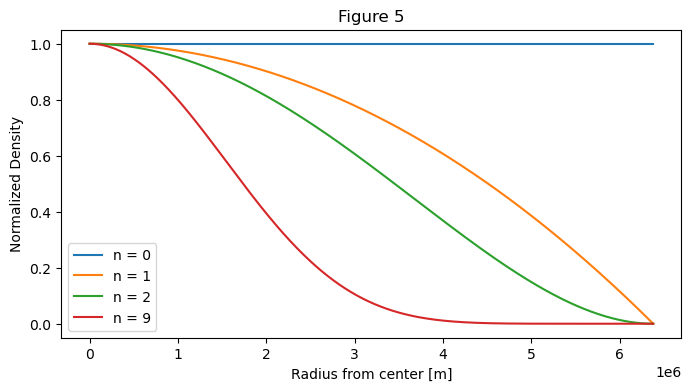

In [15]:
# points
n_vals = [0, 1, 2, 9]
r_vals = np.linspace(0, R_earth, 1000)

# plotting
fig, ax = plt.subplots(figsize=(8, 4))

for n in n_vals:
    norm_density = (1 - (r_vals / R_earth)**2)**n
    ax.plot(r_vals, norm_density, label=f'n = {n}')

ax.set_xlabel('Radius from center [m]')
ax.set_ylabel('Normalized Density')
ax.set_title('Figure 5')
ax.legend();

### Part 5, Section B (Forces)

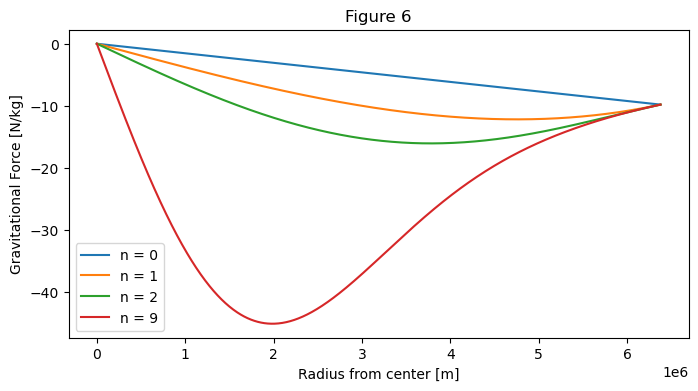

In [16]:
# for int
def mass_integrand(r, n):
    return 4 * np.pi * (r**2) * ((1 - (r / R_earth)**2)**n)

rho_n_dict = {}

# solve
for n in n_vals:
    total_unnorm_mass, err = quad(mass_integrand, 0, R_earth, args=(n,))
    rho_n_dict[n] = M_earth / total_unnorm_mass

# plotting
fig, ax = plt.subplots(figsize=(8, 4))

for n in n_vals:
    force_vals = np.zeros(len(r_vals))
    for i in range(len(r_vals)):
        r = r_vals[i]
        if r == 0:
            force_vals[i] = 0.0
        else:
            unnorm_mass_enc, err = quad(mass_integrand, 0, r, args=(n,))
            mass_enc = rho_n_dict[n] * unnorm_mass_enc
            force_vals[i] = -G * mass_enc / (r**2)
            
    ax.plot(r_vals, force_vals, label=f'n = {n}')

ax.set_xlabel('Radius from center [m]')
ax.set_ylabel('Gravitational Force [N/kg]')
ax.set_title('Figure 6')
ax.legend();

In [17]:
# analysis
print('Calculated Central Densities:')
for n in n_vals:
    print(f'n={n}: {rho_n_dict[n]:.2f} kg/m^3')

Calculated Central Densities:
n=0: 5494.87 kg/m^3
n=1: 13737.17 kg/m^3
n=2: 24040.04 kg/m^3
n=9: 135545.12 kg/m^3


### Part 5, Section C (Equations of Motion)

n=0: time to center: 1267.241 sec, max speed: 7905.971 m/s
n=1: time to center: 1096.891 sec, max speed: 10435.239 m/s
n=2: time to center: 1035.139 sec, max speed: 12200.746 m/s
n=9: time to center: 943.875 sec, max speed: 18391.997 m/s


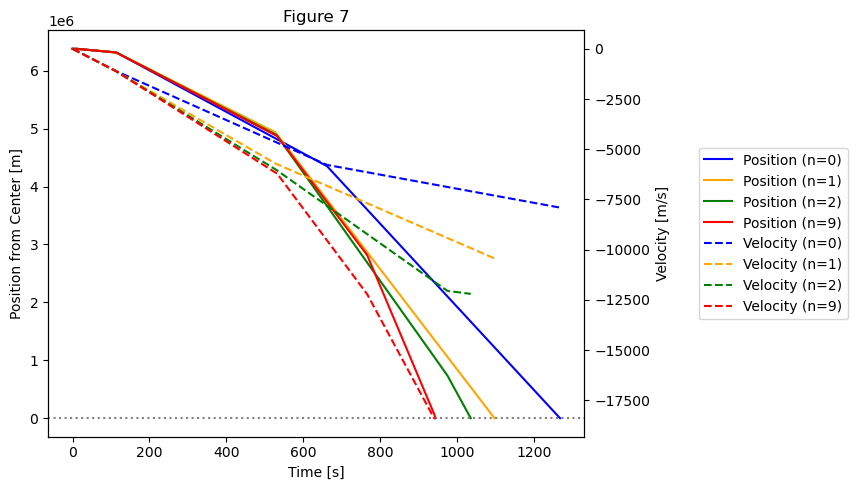

In [18]:
# non-uniform
def derivatives_non_uniform(t, z, n):
    v, y = z
    if np.abs(y) <= 0.1:  # prevent division by zero near the center
        dvdt = 0.0
    else:
        unnorm_mass, err = quad(mass_integrand, 0, np.abs(y), args=(n,))
        mass_enc = rho_n_dict[n] * unnorm_mass
        dvdt = -np.sign(y) * G * mass_enc / (y**2)
    dydt = v
    return dvdt, dydt

# event
def end_center(t, z, n):
    v, y = z
    return y

end_center.direction = -1
end_center.terminal = True

# times
t0, tf_non = 0.0, 2000.0
tt_non = np.linspace(t0, tf_non, 1000)
z0_non = [0.0, R_earth]

# plotting
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()
colors = ['b', 'orange', 'g', 'r']

# solve
for i, n in enumerate(n_vals):
    solution_non = solve_ivp(fun=derivatives_non_uniform,
                             t_span=(t0, tf_non),
                             y0=z0_non,
                             args=(n,),
                             events=end_center)
    
    ax1.plot(solution_non.t, solution_non.y[1], color=colors[i], label=f'Position (n={n})')
    ax2.plot(solution_non.t, solution_non.y[0], color=colors[i], linestyle='--', label=f'Velocity (n={n})')
    
    # analysis
    t_center = solution_non.t_events[0][0]
    v_center = solution_non.y_events[0][0][0] 
    print(f'n={n}: time to center: {t_center:.3f} sec, max speed: {np.abs(v_center):.3f} m/s')

ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Position from Center [m]')
ax2.set_ylabel('Velocity [m/s]')
ax1.set_title('Figure 7')
ax1.axhline(0, color='gray', linestyle=':')

# combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center left', bbox_to_anchor=(1.2, 0.5))

fig.tight_layout();

## Part 6: A Lunar Mine Shaft


Finally, with all of the framework in place, consider the case where the
the mine shaft is instead dug on the moon.

1. Compute the travel time to the center of the moon
                in case we dig a pole-to-pole mine shaft,
                so that we can again avoid the Coriolis force, though
                on the moon this force is very small. No drag force either,
   which is actually realistic for the moon!
3. What is the density (if you asssume a constant density) 
                of the moon compared to that of earth? 
4. How does the fall/orbit time depend on density? See if you can discover a 
        relationship between the density and the fall time. You should think beyond strictly linear 
        relationships.



This problem can actually be
done on paper, and then you can compare the answer with that for the homogenous earth
you did in Part 4.


In [19]:
g_moon = G * M_moon / (R_moon**2)

# system of fxns
def derivatives_moon(t, z, g_moon, R_moon):
    v, y = z
    dvdt = -g_moon * (y / R_moon)
    dydt = v
    return dvdt, dydt

# event
def end_center_moon(t, z, g_moon, R_moon):
    v, y = z
    return y
    
end_center_moon.direction = -1
end_center_moon.terminal = True

# times
t0, tf_moon = 0.0, 4000.0
tt_moon = np.linspace(t0, tf_moon, 1000)

# ICs
z0_moon = [0.0, R_moon]

# solve
solution_moon = solve_ivp(fun=derivatives_moon,
                          t_span=(t0, tf_moon),
                          y0=z0_moon,
                          args=(g_moon, R_moon),
                          t_eval=tt_moon,
                          events=end_center_moon)

# analysis
t_center_moon = solution_moon.t_events[0][0]
print(f'time to center: {t_center_moon:.3f} sec')

time to center: 1624.906 sec


In [20]:
# density
vol_earth = (4/3) * np.pi * (R_earth**3)
vol_moon = (4/3) * np.pi * (R_moon**3)

rho_earth = M_earth / vol_earth
rho_moon = M_moon / vol_moon

print(f'earth density: {rho_earth:.2f} kg/m^3')
print(f'moon density: {rho_moon:.2f} kg/m^3')

earth density: 5494.87 kg/m^3
moon density: 3341.75 kg/m^3


We can see the time to reach the center of the Moon is about 1625 seconds. Calculating the densities, the Earth's uniform density is roughly 5495 kg/m^3 while the Moon's is only 3342 kg/m^3. The Moon is much less dense than the Earth.

To find the relationship between fall time and density, we can write out the acceleration analytically:

$a = -\frac{GM}{r^2}$

Since $M = \frac{4}{3}\pi r^3\rho$, we can substitute it into the acceleration equation:

$a = -(\frac{4}{3}\pi G\rho)r$

This matches the exact form of simple harmonic motion $a = -\omega^2x$, where $\omega^2 = \frac{4}{3}\pi G\rho$

The time to reach the center is a quarter of the total orbital period $(\frac{T}{4})$

Since $T = \frac{2\pi}{\omega}$, the fall time is dependent on $\omega$, meaning the fall time is inversely proportional to the square root of the density.

Even though the Moon is much smaller than the Earth, because it is less dense, it actually takes longer to fall through it.

## Part 7: Fourier Transforming Orbits

Take the solutions for n=0 and n=9 of the orbits in Part 5 (the inhomogeneous earth) and Fourier Transform them, to see what frequencies (*1/periods*) are dominant in the power spectra. Comment on what you see.

**Hint:** you could take the orbit from the previous integration in Part 5c, but it is useful to increase the integration time and sampling to get more meaningful smooth enough curves. We discussed this in class.

For an example of a spectral analysis of galactic orbits see https://articles.adsabs.harvard.edu/pdf/1982ApJ...252..308B

In [21]:
# times
tf_fft = 20000.0
dt = 5.0
tt_fft = np.arange(t0, tf_fft, dt)

# solve
solution_fft_0 = solve_ivp(fun=derivatives_non_uniform,
                           t_span=(t0, tf_fft),
                           y0=z0_non,
                           args=(0,),
                           t_eval=tt_fft)

solution_fft_9 = solve_ivp(fun=derivatives_non_uniform,
                           t_span=(t0, tf_fft),
                           y0=z0_non,
                           args=(9,),
                           t_eval=tt_fft)



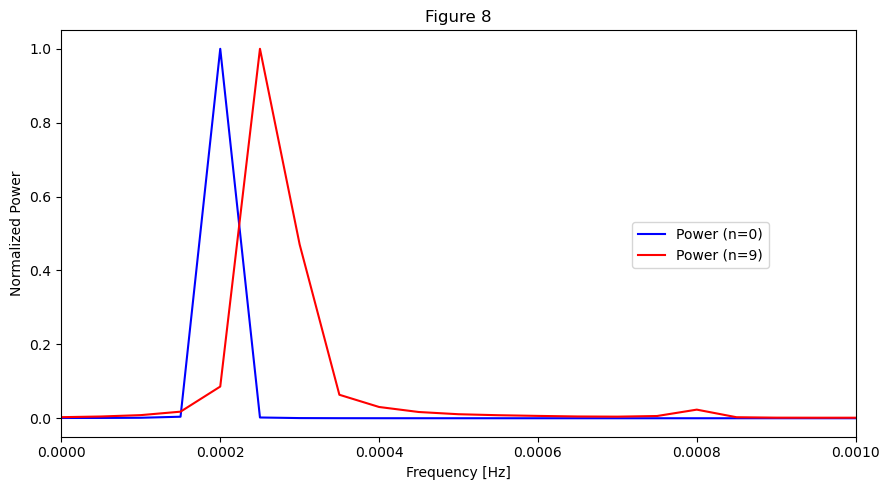

In [22]:
# analysis
N = len(tt_fft)

yf_0 = rfft(solution_fft_0.y[1])
yf_9 = rfft(solution_fft_9.y[1])

xf = rfftfreq(N, dt)

power_0 = np.abs(yf_0)**2
power_9 = np.abs(yf_9)**2

# normalize
power_0 = power_0 / np.max(power_0)
power_9 = power_9 / np.max(power_9)

# plotting
fig, ax1 = plt.subplots(figsize=(9,5))

ax1.plot(xf, power_0, color='b', label='Power (n=0)')
ax1.plot(xf, power_9, color='r', label='Power (n=9)')

ax1.set_xlim(0, 0.001)
ax1.set_xlabel('Frequency [Hz]')
ax1.set_ylabel('Normalized Power')
ax1.set_title('Figure 8')

fig.legend(loc='center left', bbox_to_anchor=(0.7, 0.5))
fig.tight_layout()

Describe what we see here:

The power spectrum for n=0 features exactly one massive, distinct spike. Because a perfectly uniform Earth acts exactly like a simple spring, the mass undergoes perfect simple harmonic motion. A pure sine wave contains only a single fundamental frequency, which is why there is only one peak.

The power spectrum for n=9 looks noticeably different. First, the primary peak is shifted to the right to a higher frequency. This confirms our finding in Part 5 that the mass falls faster and has a shorter orbital period through a dense core. Second, we see a few smaller trailing bumps to the right of the main peak. This happens because the orbit for n=9 is not a perfect sine wave, meaning there are multiple interacting frequencies involved in the motion.